In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
print("Numerical Features:")
print(df.select_dtypes(include=np.number).columns)

print()

print("Categorical Features:")
print(df.select_dtypes(include="object").columns)

print()

print("Target Variable: charges")

Numerical Features:
Index(['age', 'bmi', 'children', 'charges'], dtype='object')

Categorical Features:
Index(['sex', 'smoker', 'region'], dtype='object')

Target Variable: charges


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
# Encode categorical variables

encoder = LabelEncoder()

df["sex"] = encoder.fit_transform(df["sex"])
df["smoker"] = encoder.fit_transform(df["smoker"])
df["region"] = encoder.fit_transform(df["region"])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [8]:
# Features
X = df[["age", "sex", "bmi", "children", "smoker", "region"]]

# Target
y = df["charges"]

print(X.head())
print()
print(y.head())

   age  sex     bmi  children  smoker  region
0   19    0  27.900         0       1       3
1   18    1  33.770         1       0       2
2   28    1  33.000         3       0       2
3   33    1  22.705         0       0       1
4   32    1  28.880         0       0       1

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [9]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1070, 6)
Testing Data: (268, 6)


In [10]:
# Create the model

model = LinearRegression()

# Train the model

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
# Predict on test data

y_pred = model.predict(X_test)

print(y_pred[:5])

[ 8924.40724442  7116.29501758 36909.01352144  9507.87469118
 27013.3500079 ]


In [12]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 4186.508898366432
Mean Squared Error (MSE): 33635210.431178406
R2 Score: 0.7833463107364539


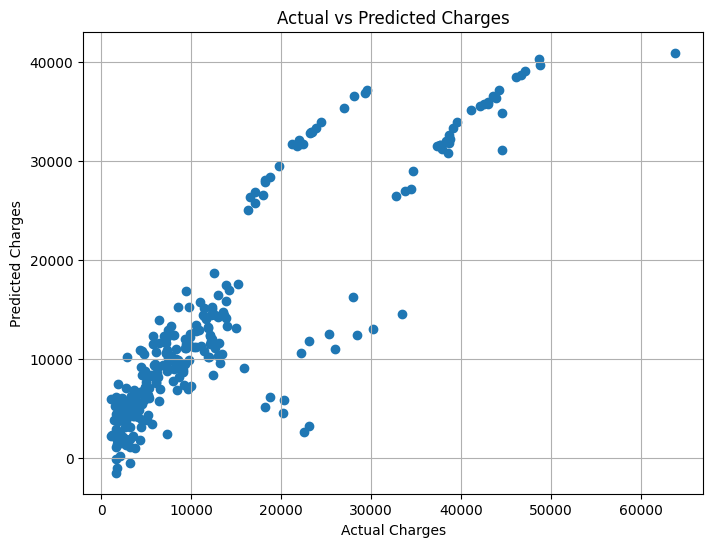

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")

plt.grid(True)

plt.show()

## Observations

1. The model achieved an R² score of approximately 0.78, indicating that it explains most of the variation in insurance charges.

2. The scatter plot shows that many predicted values are close to the actual values, which means the model performs reasonably well.

3. Some points are farther from the expected trend, especially for customers with very high insurance charges, indicating that the model has larger prediction errors for some cases.

## Conclusion

In this assignment, a Multiple Linear Regression model was developed to predict medical insurance charges using features such as age, sex, BMI, number of children, smoker status, and region. The dataset was preprocessed by checking for missing values, encoding categorical variables, and splitting the data into training and testing sets. The model achieved an R² score of approximately 0.78, showing good prediction performance. The results indicate that smoking status, age, and BMI are important factors affecting insurance charges. Although the model performs well, some predictions for higher insurance charges are less accurate. A limitation of Multiple Linear Regression is that it assumes a linear relationship between the input features and the target variable, which may not capture all real-world patterns.